
========== LOGISTIC REGRESSION ==========
Accuracy: 0.812588736393753

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1539
           1       0.68      0.57      0.62       574

    accuracy                           0.81      2113
   macro avg       0.77      0.74      0.75      2113
weighted avg       0.81      0.81      0.81      2113



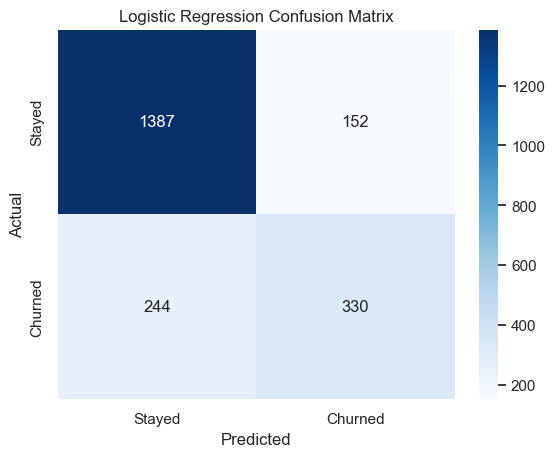


========== DECISION TREE ==========
Accuracy: 0.7893989588263133

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1539
           1       0.61      0.60      0.61       574

    accuracy                           0.79      2113
   macro avg       0.73      0.73      0.73      2113
weighted avg       0.79      0.79      0.79      2113



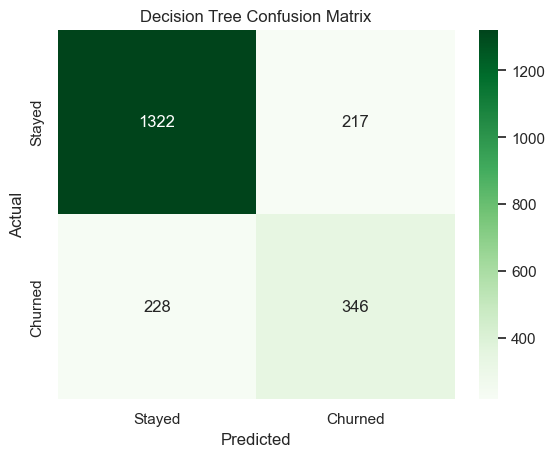


========== RANDOM FOREST ==========
Accuracy: 0.8012304779933743

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1539
           1       0.69      0.49      0.57       574

    accuracy                           0.80      2113
   macro avg       0.76      0.70      0.72      2113
weighted avg       0.79      0.80      0.79      2113



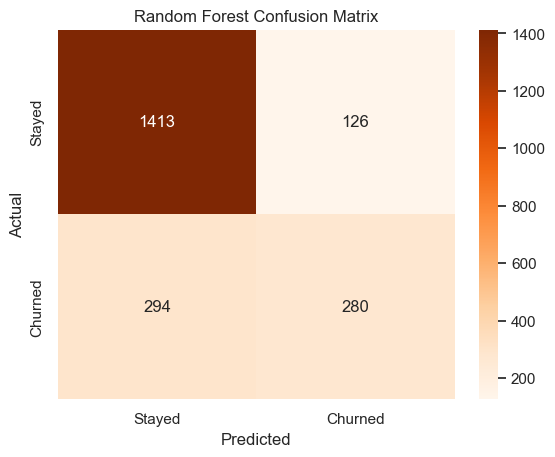

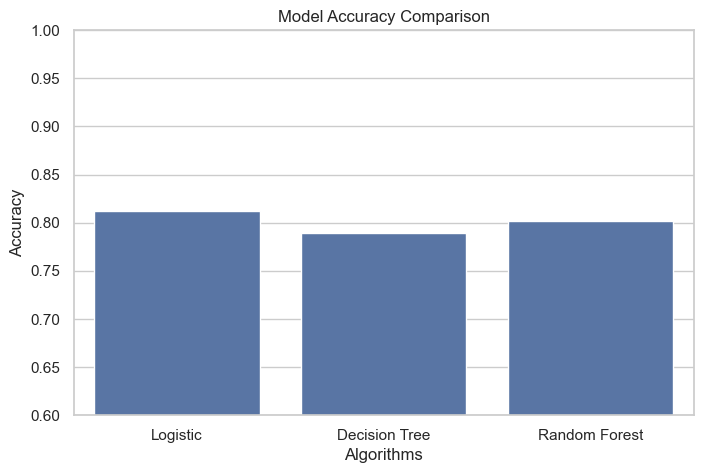


🏆 Best Model: Logistic
Best Accuracy: 0.812588736393753


In [2]:
# Customer Churn Prediction - Professional Version (Multi Model)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

# 1. Load Dataset
data = pd.read_csv("churn.csv")

# 2. Data Cleaning (Same as your new code logic)
data['TotalCharges'] = data['TotalCharges'].replace(' ', '0')
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'])

data.drop('customerID', axis=1, inplace=True)

# Encode Target
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# One Hot Encoding
data = pd.get_dummies(data, drop_first=True)

# 3. Split Data (70-30 like your new code)
X = data.drop('Churn', axis=1)
Y = data['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

accuracy_list = []
model_names = []

# =====================================================
# 🔵 Logistic Regression
# =====================================================
print("\n========== LOGISTIC REGRESSION ==========")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, Y_train)

pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(Y_test, pred_lr)
print("Accuracy:", acc_lr)
print("\nClassification Report:\n")
print(classification_report(Y_test, pred_lr))

accuracy_list.append(acc_lr)
model_names.append("Logistic")

cm = confusion_matrix(Y_test, pred_lr)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 🌳 Decision Tree
# =====================================================
print("\n========== DECISION TREE ==========")

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, Y_train)

pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(Y_test, pred_dt)
print("Accuracy:", acc_dt)
print("\nClassification Report:\n")
print(classification_report(Y_test, pred_dt))

accuracy_list.append(acc_dt)
model_names.append("Decision Tree")

cm = confusion_matrix(Y_test, pred_dt)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 🌲 Random Forest
# =====================================================
print("\n========== RANDOM FOREST ==========")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)
rf.fit(X_train, Y_train)

pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(Y_test, pred_rf)
print("Accuracy:", acc_rf)
print("\nClassification Report:\n")
print(classification_report(Y_test, pred_rf))

accuracy_list.append(acc_rf)
model_names.append("Random Forest")

cm = confusion_matrix(Y_test, pred_rf)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'],
            cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 📊 Accuracy Comparison Graph
# =====================================================
plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=accuracy_list)
plt.title("Model Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.ylim(0.6, 1)
plt.show()

print("\n🏆 Best Model:", model_names[np.argmax(accuracy_list)])
print("Best Accuracy:", max(accuracy_list))